In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns
from  sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv('Breast_cancer_data.csv')

In [ ]:
df

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0
...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0
565,20.13,28.25,131.20,1261.0,0.09780,0
566,16.60,28.08,108.30,858.1,0.08455,0
567,20.60,29.33,140.10,1265.0,0.11780,0


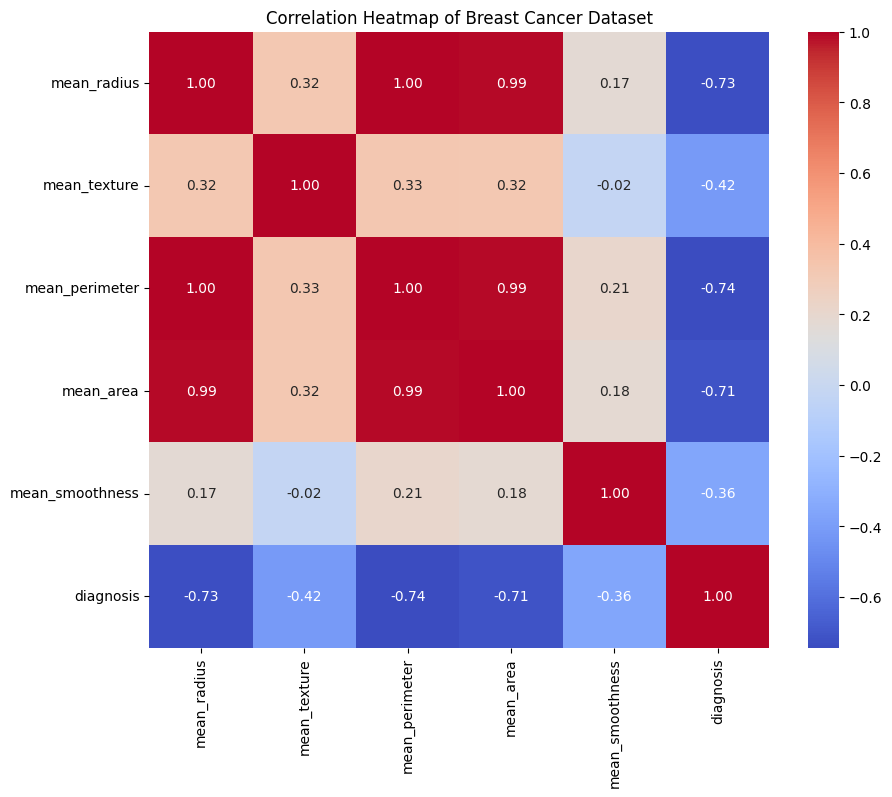

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix_bc = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_bc, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Breast Cancer Dataset')
plt.show()

In [ ]:
df_final=df[['mean_radius','mean_texture','mean_smoothness','diagnosis']]
df_final.head()

,mean_radius,mean_texture,mean_smoothness,diagnosis
0,17.99,10.38,0.11840,0
1,20.57,17.77,0.08474,0
2,19.69,21.25,0.10960,0
3,11.42,20.38,0.14250,0
4,20.29,14.34,0.10030,0


In [ ]:
X=df_final.drop('diagnosis',axis=1)
y=df_final['diagnosis']

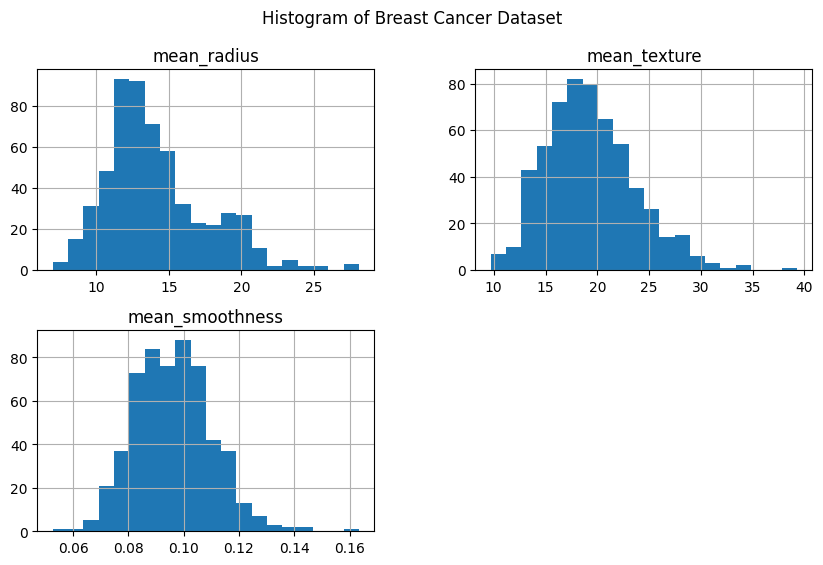

In [ ]:
X.hist(bins=20,figsize=(10,6))
plt.suptitle('Histogram of Breast Cancer Dataset')
plt.show()

<Axes: xlabel='mean_radius', ylabel='Count'>

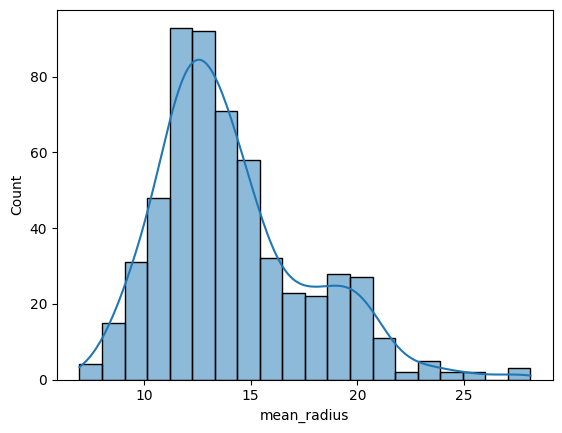

In [ ]:
sns.histplot(X['mean_radius'], bins=20, kde=True)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=0)

In [ ]:
from sklearn.naive_bayes import GaussianNB
classifier=GaussianNB()
classifier.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred=classifier.predict(X_test)

In [ ]:
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 1])

In [ ]:
y_test

,diagnosis
512,0
457,1
439,1
298,1
37,1
...,...
213,0
519,1
432,0
516,0


In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
ac=accuracy_score(y_test,y_pred)

In [ ]:
cm

array([[39,  8],
       [ 2, 65]])

In [ ]:
ac

0.9122807017543859

In [ ]:
import math
import random
import pandas as pd
import numpy as np

In [ ]:
def calculate_prior(df, Y):
  classes = sorted(list(df[Y].unique()))
  prior = []
  for i in classes:
    prior.append(len(df[df[Y]==i]) / len(df))
  return prior

def calculate_likelihood_gaussian(df, feat_name,feat_val,Y, label):
  feat = list(df.columns)
  df = df[df[Y] == label]
  mean, std = df[feat_name].mean(),df[feat_name].std()
  p_x_given_y = (1/ ( np.sqrt(2 * np.pi) * std)) * np.exp(-((feat_val - mean)**2 / (2 * std**2)))
  return p_x_given_y

def naive_bayes_gaussian(df, X, Y):
    features = list(df.columns)[:-1]
    labels = sorted(list(df[Y].unique()))
    prior = calculate_prior(df, Y)

    Y_pred = []

    for x in X:
        post_prob = []

        for j, label in enumerate(labels):
            likelihood = 1

            for i, feature in enumerate(features):
                likelihood *= calculate_likelihood_gaussian(
                    df, feature, x[i], Y, label
                )

            post_prob.append(likelihood * prior[j])

        Y_pred.append(labels[np.argmax(post_prob)])

    return np.array(Y_pred)

In [ ]:
df.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [ ]:
train,test = train_test_split(df, test_size=0.2, random_state=41)
X_test_acc = test.iloc[:,:-1].values
Y_test_acc = test.iloc[:,-1].values

In [ ]:
Y_pred_acc = naive_bayes_gaussian(train, X=X_test_acc, Y="diagnosis")

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(Y_test_acc,Y_pred_acc)
ac=accuracy_score(Y_test_acc,Y_pred_acc)

In [ ]:
cm

array([[36,  4],
       [ 2, 72]])

In [ ]:
ac

0.9473684210526315

In [ ]:
dataset =pd.read_csv('Social_Network_Ads.csv')

In [ ]:
dataset

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
dataset['Gender']=le.fit_transform(dataset['Gender'])
X=dataset.iloc[:,[1,2,3]].values
y=dataset.iloc[:,-1].values
dataset[['Gender']].head()

,Gender
0,1
1,1
2,0
3,0
4,1


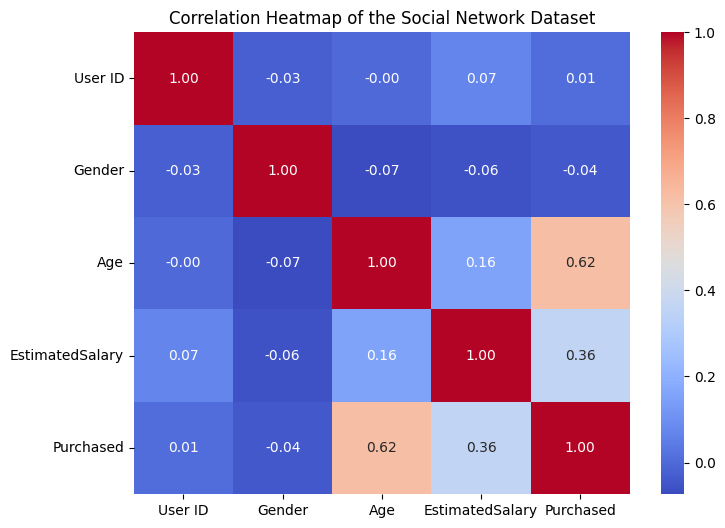

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
correlation_matrix = dataset.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of the Social Network Dataset')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


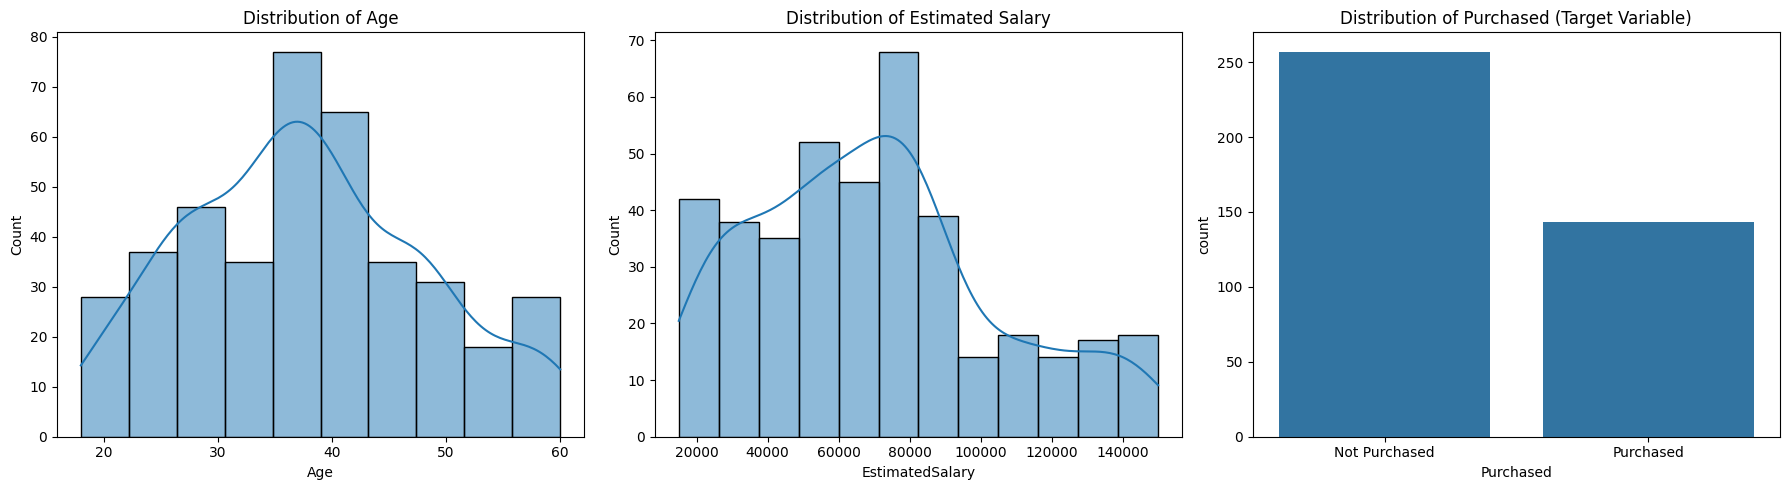

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(dataset['Age'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Age')

sns.histplot(dataset['EstimatedSalary'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Estimated Salary')

sns.countplot(x=dataset['Purchased'], ax=axes[2])
axes[2].set_title('Distribution of Purchased (Target Variable)')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Not Purchased', 'Purchased'])

plt.tight_layout()
plt.show()

In [ ]:
classifier=GaussianNB()
classifier.fit(X_train,y_train)

GaussianNB()

In [ ]:
y_pred=classifier.predict(X_test)

In [ ]:
cm=confusion_matrix(y_test,y_pred)
ac=accuracy_score(y_test,y_pred)

In [ ]:
ac

0.925

In [ ]:
cm

array([[56,  2],
       [ 4, 18]])